In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# Notebook U — Volatility/Timing Feature Consolidation

A paired development-only test of whether a fixed 28-feature domain contract can replace the frozen 248-feature timing inputs without losing predictive quality, trade frequency, or net economics.

In [2]:
# Validated artifact reader
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

RUN_ROOT_BASE = 'code'
RUN_ROOT_RELATIVE = 'experiments/cache/event_window_feature_consolidation'
if RUN_ROOT_BASE == "code":
    RUN_ROOT = (CODE_ROOT / RUN_ROOT_RELATIVE).resolve()
else:
    RUN_ROOT = (Path.cwd().resolve() / RUN_ROOT_RELATIVE).resolve()

EXPECTED_FRAME_COLUMNS = {'compact_feature_audit.csv': ('feature', 'source_type', 'included', 'finite_fraction', 'missing_fraction', 'known_at_decision_time', 'direction_invariant'), 'feature_redundancy_audit.csv': ('scope', 'pairs_abs_spearman_ge_0_90', 'features_in_pairs', 'maximum_abs_spearman', 'diagnostic_only'), 'base_reproduction_audit.csv': ('source', 'model', 'row_identity', 'max_abs_difference', 'required'), 'predictive_metrics.csv': ('arm', 'model', 'feature_set', 'fold_id', 'weighted_brier', 'weighted_log_loss'), 'predictive_deltas.csv': ('model', 'fold_id', 'brier_improvement', 'log_loss_improvement', 'nonnegative_brier_folds'), 'economic_metrics.csv': ('arm', 'scenario', 'observed_trades', 'activations_per_calendar_day', 'path_completeness', 'mean_net_r', 'net_mean_r_ci_low', 'net_mean_r_ci_high'), 'feature_comparisons.csv': ('comparison', 'candidate_arm', 'control_arm', 'scenario', 'delta_mean_net_r', 'delta_mean_net_r_ci_low', 'delta_mean_net_r_ci_high'), 'frequency_audit.csv': ('arm', 'activations', 'activations_per_calendar_day'), 'leakage_audit.csv': ('check', 'passed', 'detail')}
REQUIRED_READER_ARTIFACTS = ('oof_predictions.parquet', 'policy_calibration_predictions.parquet', 'compact_feature_audit.csv', 'feature_redundancy_audit.csv', 'base_reproduction_audit.csv', 'fold_audit.csv', 'head_calibration_audit.csv', 'predictive_metrics.csv', 'predictive_deltas.csv', 'threshold_audit.csv', 'activation_ledger.parquet', 'economic_paths.parquet', 'economic_metrics.csv', 'feature_comparisons.csv', 'frequency_audit.csv', 'concurrency_audit.csv', 'leakage_audit.csv', 'protocol.json', 'frozen_protocol.json', 'summary.json')
FROZEN_P_RUN_HASH = '0474798f6d0eb56e64d3'
FROZEN_R_RUN_HASH = 'f8de389583c836f48140'
DERIVED_FEATURES = {
    "channel_center_distance",
    "nearest_rail_distance_bps",
    "rail_approach_15m",
}

def _sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def _load_completed_run():
    pointer_path = RUN_ROOT / "latest_dev.json"
    if not pointer_path.is_file():
        return None, None, None, {}, None, None, "latest_dev.json is missing"
    try:
        pointer = json.loads(pointer_path.read_text(encoding="utf-8"))
        run_hash = str(pointer.get("run_hash", ""))
        protocol_hash = str(pointer.get("protocol_hash", ""))
        relative_path = Path(str(pointer.get("relative_path", "")))
        if relative_path.is_absolute() or ".." in relative_path.parts:
            raise ValueError("pointer path is unsafe")
        run_dir = (RUN_ROOT / relative_path).resolve()
        if run_dir != (RUN_ROOT / run_hash / "full").resolve():
            raise ValueError("pointer does not identify the matching full run")

        state = json.loads((run_dir / "run_state.json").read_text(encoding="utf-8"))
        if state.get("status") != "complete":
            raise ValueError("run state is not complete")
        if state.get("run_hash") != run_hash or state.get("protocol_hash") != protocol_hash:
            raise ValueError("run state identity does not match the pointer")
        records = state.get("artifacts", {})
        for name in REQUIRED_READER_ARTIFACTS:
            path = run_dir / name
            record = records.get(name, {})
            if not path.is_file() or not record:
                raise ValueError(f"required artifact is missing: {name}")
            if int(record.get("size", -1)) != path.stat().st_size:
                raise ValueError(f"artifact size does not match: {name}")
            if str(record.get("sha256", "")) != _sha256(path):
                raise ValueError(f"artifact hash does not match: {name}")

        protocol = json.loads((run_dir / "protocol.json").read_text(encoding="utf-8"))
        frozen = json.loads((run_dir / "frozen_protocol.json").read_text(encoding="utf-8"))
        summary = json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))
        if state.get("summary") != summary:
            raise ValueError("summary does not match completed run state")
        if frozen.get("frozen_p_run_hash") != FROZEN_P_RUN_HASH:
            raise ValueError("frozen Notebook P identity changed")
        if frozen.get("frozen_r_run_hash") != FROZEN_R_RUN_HASH:
            raise ValueError("frozen Notebook R identity changed")
        for payload in (protocol, frozen, summary):
            if payload.get("forward_or_lockbox_loaded") is not False:
                raise ValueError("later-period data are not accepted")
        if summary.get("p_hit_frozen") is not True:
            raise ValueError("Notebook U changed frozen p_hit")
        if summary.get("timing_model_refit") is not True:
            raise ValueError("Notebook U timing refit is incomplete")
        if summary.get("calendar_features_included") is not False:
            raise ValueError("Notebook U must keep calendar excluded")
        if summary.get("impulse_features_included") is not False:
            raise ValueError("Notebook U must keep impulse excluded")
        if summary.get("economics_evaluated") is not True:
            raise ValueError("Notebook U economics are incomplete")
        if summary.get("base_feature_count") != 248 or summary.get("compact_feature_count") != 28:
            raise ValueError("Notebook U feature counts changed")
        if summary.get("derived_feature_count") != 3:
            raise ValueError("Notebook U derived-feature count changed")

        frames = {}
        for name, required_columns in EXPECTED_FRAME_COLUMNS.items():
            frame = pd.read_csv(run_dir / name)
            missing = [column for column in required_columns if column not in frame]
            if missing:
                raise ValueError(f"artifact schema does not match: {name}")
            frames[name] = frame
        feature_audit = frames["compact_feature_audit.csv"]
        if len(feature_audit) != 28 or set(
            feature_audit.loc[feature_audit["source_type"].eq("derived"), "feature"]
        ) != DERIVED_FEATURES:
            raise ValueError("compact feature audit does not match the fixed contract")
        for column in ("included", "known_at_decision_time", "direction_invariant"):
            if not feature_audit[column].astype(bool).all():
                raise ValueError(f"compact feature audit failed: {column}")
        if not frames["leakage_audit.csv"]["passed"].astype(bool).all():
            raise ValueError("leakage audit contains a failed check")

        predictions = pd.read_parquet(run_dir / "oof_predictions.parquet")
        ledger = pd.read_parquet(run_dir / "activation_ledger.parquet")
        for name, frame, columns in (
            ("OOF predictions", predictions, ("arm", "fold_id", "p_t_le_60")),
            ("activation ledger", ledger, ("activation_key", "arm", "decision_time")),
        ):
            missing = [column for column in columns if column not in frame]
            if missing:
                raise ValueError(f"{name} schema does not match")
        # JSON stores metadata only; analytical rows remain tabular.
        return run_dir, protocol, summary, frames, predictions, ledger, None
    except Exception as error:
        return None, None, None, {}, None, None, str(error)

RUN_DIR, PROTOCOL, SUMMARY, FRAMES, PREDICTIONS, LEDGER, READER_NOTE = _load_completed_run()
READER_READY = RUN_DIR is not None
if READER_READY:
    pass
else:
    print(f"Completed Notebook U artifacts are not available: {READER_NOTE}.")
    print("Run: python -m experiments.run_event_window_feature_consolidation --stage dev")

## 1. Paired timing experiment

Frozen opportunity probabilities are retained while LogReg and XGBoost timing heads at 15/30/60 minutes compare 248 versus 28 features on identical OOF rows; level re-arm keeps a 60-minute cooldown.

In [3]:
from IPython.display import Markdown
if READER_READY:
    handoff = pd.Series({
        "development rows": SUMMARY["decision_rows"],
        "OOF folds": SUMMARY["folds"],
        "base features": SUMMARY["base_feature_count"],
        "compact features": SUMMARY["compact_feature_count"],
        "p_hit frozen": SUMMARY["p_hit_frozen"],
        "timing heads refit": ", ".join(PROTOCOL["timing_heads_refit"]),
        "policy": PROTOCOL["alert_policy"],
        "later periods loaded": SUMMARY["forward_or_lockbox_loaded"],
    }, name="Frozen development protocol")
    display(Markdown('Method: The fixed opportunity probabilities are retained while three timing heads compare 248 versus 28 features.'))
    display(handoff.to_frame())
    display(Markdown('Only the timing feature set changes.'))
else:
    pass

Method: The fixed opportunity probabilities are retained while three timing heads compare 248 versus 28 features.

,Frozen development protocol
development rows,171658
OOF folds,7
base features,248
compact features,28
p_hit frozen,True
timing heads refit,"h15, h30, h60"
policy,level_rearm
later periods loaded,False


Only the timing feature set changes.

## 2. Exact 28-feature contract and exclusions

The candidate contains 25 native volatility/activity/timing fields plus three row-causal transforms: `channel_center_distance`, `nearest_rail_distance_bps`, and `rail_approach_15m`. Calendar excluded; impulse excluded. Direction, RSI, OI, funding, positioning and sentiment are also excluded because this head answers only *how large and how soon*.

In [4]:
from IPython.display import Markdown
if READER_READY:
    feature_audit = FRAMES["compact_feature_audit.csv"].copy()
    display(Markdown('Method: Each compact feature is checked for source, missingness and long/short-reflection invariance.'))
    display(feature_audit[[
        "feature", "source_type", "finite_fraction", "missing_fraction",
        "known_at_decision_time", "direction_invariant",
    ]])
    display(Markdown('The compact contract contains 25 native fields and three causal transforms.'))
else:
    pass

Method: Each compact feature is checked for source, missingness and long/short-reflection invariance.

,feature,source_type,finite_fraction,missing_fraction,known_at_decision_time,direction_invariant
0,adaptive_barrier_bps,native,0.999988,0.000012,True,True
1,past_sigma_5m_bps,native,0.999988,0.000012,True,True
2,past_rv_15_bps,native,0.999988,0.000012,True,True
3,past_rv_30_bps,native,0.999988,0.000012,True,True
4,past_rv_60_bps,native,0.999988,0.000012,True,True
5,past_rv_120_bps,native,0.999988,0.000012,True,True
6,rv_ratio_15_60,native,0.999971,0.000029,True,True
7,rv_ratio_60_120,native,0.999988,0.000012,True,True
8,past_range_15_bps,native,0.999988,0.000012,True,True
9,past_range_60_bps,native,0.999988,0.000012,True,True


The compact contract contains 25 native fields and three causal transforms.

## 3. Causality, symmetry and effective sample

All inputs are known at decision time, derived transforms are invariant to long/short reflection, missing history remains explicit, and imputation is fold-local. Seven expanding episode-purged OOF folds prevent one channel episode from appearing on both sides. Correlation is diagnostic only: no feature is selected using outcomes.

In [5]:
from IPython.display import Markdown
if READER_READY:
    display(Markdown('Method: Spearman redundancy is measured on a fixed sample without selecting features from later outcomes.'))
    display(FRAMES["feature_redundancy_audit.csv"])
    display(Markdown('Several compact features remain correlated.'))
    reproduction = FRAMES["base_reproduction_audit.csv"]
    display(Markdown('Method: Control predictions are compared row-for-row with the frozen reference.'))
    display(reproduction[[
        "source", "model", "row_identity", "max_abs_difference", "required"
    ]])
    display(Markdown('The base predictions reproduce exactly.'))
    leakage = FRAMES["leakage_audit.csv"]
else:
    pass

Method: Spearman redundancy is measured on a fixed sample without selecting features from later outcomes.

,scope,left_features,right_features,pairs_evaluated,pairs_abs_spearman_ge_0_90,features_in_pairs,maximum_abs_spearman,sample_rows,diagnostic_only
0,within_base,248,248,29887,273,149,1.0,20000,True
1,compact_vs_base,28,248,6860,105,65,1.0,20000,True
2,within_compact,28,28,378,21,14,1.0,20000,True


Several compact features remain correlated.

Method: Control predictions are compared row-for-row with the frozen reference.

,source,model,row_identity,max_abs_difference,required
0,outer,logreg,True,0.0,True
1,outer,xgboost,True,0.0,True
2,policy_calibration,logreg,True,0.0,True
3,policy_calibration,xgboost,True,0.0,True


The base predictions reproduce exactly.

## 4. Paired timing results

Primary predictive metrics are uniqueness-weighted Brier score and log loss for $P(T\leq60\mid hit)$. A compact model must improve both overall metrics and avoid a negative Brier delta in at least four of seven folds. Accuracy and win rate do not select the timing head.

Method: Uniqueness-weighted Brier and log loss are pooled over held-out development predictions.

,arm,model,feature_set,weighted_brier,weighted_log_loss
0,logreg_base,logreg,base,0.085276,0.302731
8,logreg_compact,logreg,compact_volatility_timing_v1,0.084630,0.300247
16,xgboost_base,xgboost,base,0.084522,0.299872
24,xgboost_compact,xgboost,compact_volatility_timing_v1,0.084545,0.300143


Compact LogReg improves, but compact XGBoost slightly worsens both losses.

Method: Paired improvements are computed on identical rows and counted across folds.

,model,fold_id,base_arm,compact_arm,rows,brier_improvement,log_loss_improvement,pr_auc_improvement,roc_auc_improvement,nonnegative_brier_folds,total_folds
0,logreg,overall,logreg_base,logreg_compact,128007,0.000646,0.002483,0.007073,0.003271,4,7
8,xgboost,overall,xgboost_base,xgboost_compact,128007,-0.000023,-0.000271,0.000647,-0.001177,3,7


XGBoost does not satisfy the required fold-consistency gate.

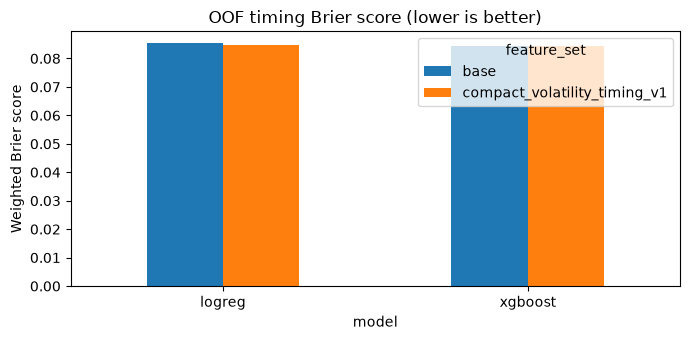

In [6]:
from IPython.display import Markdown
if READER_READY:
    metrics = FRAMES["predictive_metrics.csv"]
    overall = metrics.loc[metrics["fold_id"].astype(str).eq("overall")]
    display(Markdown('Method: Uniqueness-weighted Brier and log loss are pooled over held-out development predictions.'))
    display(overall[[
        "arm", "model", "feature_set", "weighted_brier", "weighted_log_loss"
    ]].sort_values(["model", "feature_set"]))
    display(Markdown('Compact LogReg improves, but compact XGBoost slightly worsens both losses.'))
    deltas = FRAMES["predictive_deltas.csv"]
    display(Markdown('Method: Paired improvements are computed on identical rows and counted across folds.'))
    display(deltas.loc[deltas["fold_id"].astype(str).eq("overall")])
    display(Markdown('XGBoost does not satisfy the required fold-consistency gate.'))
    chart = overall.pivot(index="model", columns="feature_set", values="weighted_brier")
    chart.plot(kind="bar", figsize=(7, 3.5), title="OOF timing Brier score (lower is better)")
    plt.ylabel("Weighted Brier score")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    pass

## 5. Level re-arm frequency and economics

Economic replay keeps RR2, a 120-minute hold, native 1-minute paths and 5/2/5 bps entry/target/other costs. The primary causal side is the channel side. The direction-70 result is a stress test only, never a trained direction claim. Frequency must remain between 2.5 and 3.5 activations per day.

Method: The fixed level-rearm rule counts activations per calendar day for each timing arm.

,arm,activations,activations_per_calendar_day
0,logreg_base,3753,2.943529
1,logreg_compact,3402,2.668235
2,xgboost_base,3431,2.690980
3,xgboost_compact,3361,2.636078


The compact variants reduce rather than increase activity.

Method: RR2, 120-minute paths and registered execution-cost scenarios are identical across arms.

,arm,scenario,observed_trades,activations_per_calendar_day,path_completeness,mean_net_r,net_mean_r_ci_low,net_mean_r_ci_high
0,logreg_base,channel_side,3753,2.943529,1.0,-0.077464,-0.104147,-0.050708
4,logreg_compact,channel_side,3402,2.668235,1.0,-0.075133,-0.105308,-0.046519
8,xgboost_base,channel_side,3431,2.690980,1.0,-0.075431,-0.106382,-0.047540
12,xgboost_compact,channel_side,3361,2.636078,1.0,-0.075602,-0.104074,-0.046759
1,logreg_base,direction_70,3753,2.943529,1.0,0.156082,0.143518,0.168475
5,logreg_compact,direction_70,3402,2.668235,1.0,0.153013,0.139795,0.167384
9,xgboost_base,direction_70,3431,2.690980,1.0,0.153870,0.140409,0.167017
13,xgboost_compact,direction_70,3361,2.636078,1.0,0.156482,0.142508,0.169504
2,logreg_base,oracle,3753,2.943529,1.0,0.497912,0.476123,0.519484
6,logreg_compact,oracle,3402,2.668235,1.0,0.493158,0.467494,0.516493


Cost assumptions materially affect apparent economics.

Method: Compact-minus-base mean Net R uses paired resampling intervals.

,comparison,scenario,delta_mean_net_r,delta_mean_net_r_ci_low,delta_mean_net_r_ci_high
0,primary_xgboost_compact,channel_side,-0.000170,-0.011265,0.011283
1,secondary_logreg_compact,channel_side,0.002331,-0.011050,0.015822
2,compact_model_sensitivity,channel_side,-0.000469,-0.010117,0.009388
3,primary_xgboost_compact,direction_70,0.002612,-0.003015,0.008399
4,secondary_logreg_compact,direction_70,-0.003069,-0.009413,0.003389
5,compact_model_sensitivity,direction_70,0.003469,-0.001410,0.008014
6,primary_xgboost_compact,oracle,0.004794,-0.004785,0.013862
7,secondary_logreg_compact,oracle,-0.004754,-0.016590,0.006350
8,compact_model_sensitivity,oracle,0.007049,-0.000742,0.015127
9,primary_xgboost_compact,random_50,0.001157,-0.002608,0.004791


The primary paired comparison does not establish an economic gain.

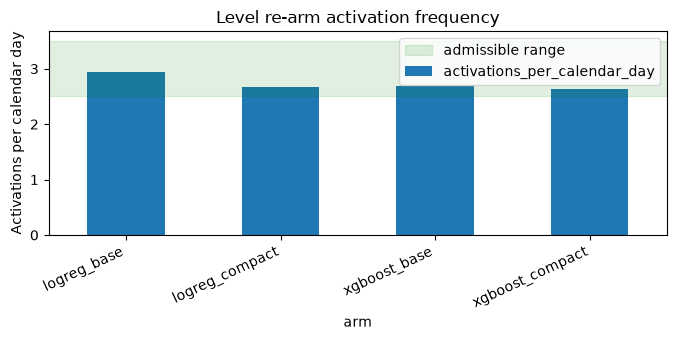

In [7]:
from IPython.display import Markdown
if READER_READY:
    frequency = FRAMES["frequency_audit.csv"].copy()
    display(Markdown('Method: The fixed level-rearm rule counts activations per calendar day for each timing arm.'))
    display(frequency[["arm", "activations", "activations_per_calendar_day"]])
    display(Markdown('The compact variants reduce rather than increase activity.'))
    economics = FRAMES["economic_metrics.csv"].copy()
    display(Markdown('Method: RR2, 120-minute paths and registered execution-cost scenarios are identical across arms.'))
    display(economics[[
        "arm", "scenario", "observed_trades", "activations_per_calendar_day",
        "path_completeness", "mean_net_r", "net_mean_r_ci_low", "net_mean_r_ci_high",
    ]].sort_values(["scenario", "arm"]))
    display(Markdown('Cost assumptions materially affect apparent economics.'))
    comparisons = FRAMES["feature_comparisons.csv"]
    display(Markdown('Method: Compact-minus-base mean Net R uses paired resampling intervals.'))
    display(comparisons[[
        "comparison", "scenario", "delta_mean_net_r",
        "delta_mean_net_r_ci_low", "delta_mean_net_r_ci_high",
    ]])
    display(Markdown('The primary paired comparison does not establish an economic gain.'))
    frequency.set_index("arm")["activations_per_calendar_day"].plot(
        kind="bar", figsize=(7, 3.5), title="Level re-arm activation frequency"
    )
    plt.axhspan(2.5, 3.5, color="green", alpha=0.12, label="admissible range")
    plt.ylabel("Activations per calendar day")
    plt.xticks(rotation=25, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    pass

## 6. Decision

Promotion jointly requires better proper scores, at least four non-negative Brier folds, adequate frequency, complete paths, valid causal checks and a positive paired economic lower bound; later periods are not evaluated in this branch.

In [8]:
from IPython.display import Markdown
if READER_READY:
    decision = pd.Series({
        "compact promoted": SUMMARY["compact_promoted"],
        "decision": SUMMARY["decision"],
        "XGBoost Brier improvement": SUMMARY["xgboost_brier_improvement"],
        "XGBoost log-loss improvement": SUMMARY["xgboost_log_loss_improvement"],
        "non-negative Brier folds": SUMMARY["xgboost_nonnegative_brier_folds"],
        "compact minus base mean net R": SUMMARY["xgboost_compact_minus_base_mean_r"],
        "episode CI low": SUMMARY["xgboost_compact_minus_base_ci_low"],
        "episode CI high": SUMMARY["xgboost_compact_minus_base_ci_high"],
        "base reproduced": SUMMARY["base_reproduction_passed"],
        "forward or Q2 loaded": SUMMARY["forward_or_lockbox_loaded"],
    }, name="Notebook U decision")
    display(Markdown('Method: Predictive, frequency and economic requirements jointly determine compact-model promotion.'))
    display(decision.to_frame())
    display(Markdown('The compact replacement fails the registered gate.'))
else:
    pass

Method: Predictive, frequency and economic requirements jointly determine compact-model promotion.

,Notebook U decision
compact promoted,False
decision,retain 248-feature control; compact candidate ...
XGBoost Brier improvement,-0.000023
XGBoost log-loss improvement,-0.000271
non-negative Brier folds,3
compact minus base mean net R,-0.00017
episode CI low,-0.011265
episode CI high,0.011283
base reproduced,True
forward or Q2 loaded,False


The compact replacement fails the registered gate.